In [ ]:
#Convolution Neural Network using PyTorch for MNIST Dataset

#Import packages
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision as torchvision
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision.models as models

In [3]:
#Setup the CNN Sub class for MNIST Dataset

class CNNNeuralNet(nn.Module):

    def __init__(self, in_size=1, out1_size=64, out2_size=128):
        super().__init__()

        self.cnn1 = nn.Conv2d(in_channels=in_size,out_channels=out1_size,kernel_size=3,padding=1) # 64x28x28
        self.maxpool1 = nn.MaxPool2d(kernel_size=2,stride=2) # stride=2 reduces dim by half 64x14x14

        self.cnn2 = nn.Conv2d(in_channels=out1_size,out_channels=out2_size,kernel_size=3,stride=1,padding=1) # 128x14x14
        self.maxpool2 = nn.MaxPool2d(kernel_size=2,stride=2) # 128x7x7

        self.flatten  = nn.Flatten()

        self.fc1 =  nn.Linear(out2_size*7*7,64) # 128*7*7 -> 64
        self.fc2 =  nn.Linear(64,32) # 64 -> 32
        self.fc3 =  nn.Linear(32,10) # 32 -> 10 ( 10 output channels in MNIST)

        

    def forward(self,x):
        
        x = torch.relu(self.cnn1(x))
        x = self.maxpool1(x)
    
        x = torch.relu(self.cnn2(x))
        x = self.maxpool2(x)

        x = self.flatten(x)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [11]:
# setup the dataset

# New transform - converts grayscale to 3 channels + resizes for ResNet
transform = transforms.Compose([
    transforms.Resize((32, 32)),         # ResNet expects 224x224, MNIST is 28x28
    transforms.Grayscale(num_output_channels=3),  # 1 channel → 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean/std
                         std=[0.229, 0.224, 0.225])
])

train_dataset = dsets.MNIST(root = './Data',download=True,train=True,transform=transform)
test_dataset = dsets.MNIST(root = './Data',download=True,train=False,transform=transform)

train_loader = DataLoader(dataset=train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(dataset=test_dataset,batch_size=128,shuffle=False)

In [27]:
#Setup model training parameters

# load a pretrained ResNet-18 model and move it to the selected device
model_pretrained = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)


for param in model_pretrained.parameters():
    param.requires_grad = False # freeze the parameters of the pretrained model so they are not updated during training

for param in model_pretrained.layer4.parameters():
    param.requires_grad = True

model_pretrained.fc = nn.Linear(model_pretrained.fc.in_features, 10)

print(f"Pretrained model architecture: {model_pretrained.state_dict()}")

criterion = nn.CrossEntropyLoss()

optimizer_pretrained = optim.Adam([parameters for parameters in model_pretrained.parameters() if parameters.requires_grad],lr=0.001) # set up the optimizer to update only the parameters of the pretrained model

epochs = 5

Pretrained model architecture: OrderedDict({'conv1.weight': tensor([[[[-1.0419e-02, -6.1356e-03, -1.8098e-03,  ...,  5.6615e-02,
            1.7083e-02, -1.2694e-02],
          [ 1.1083e-02,  9.5276e-03, -1.0993e-01,  ..., -2.7124e-01,
           -1.2907e-01,  3.7424e-03],
          [-6.9434e-03,  5.9089e-02,  2.9548e-01,  ...,  5.1972e-01,
            2.5632e-01,  6.3573e-02],
          ...,
          [-2.7535e-02,  1.6045e-02,  7.2595e-02,  ..., -3.3285e-01,
           -4.2058e-01, -2.5781e-01],
          [ 3.0613e-02,  4.0960e-02,  6.2850e-02,  ...,  4.1384e-01,
            3.9359e-01,  1.6606e-01],
          [-1.3736e-02, -3.6746e-03, -2.4084e-02,  ..., -1.5070e-01,
           -8.2230e-02, -5.7828e-03]],

         [[-1.1397e-02, -2.6619e-02, -3.4641e-02,  ...,  3.2521e-02,
            6.6221e-04, -2.5743e-02],
          [ 4.5687e-02,  3.3603e-02, -1.0453e-01,  ..., -3.1253e-01,
           -1.6051e-01, -1.2826e-03],
          [-8.3730e-04,  9.8420e-02,  4.0210e-01,  ...,  7.0789e-01

In [28]:
#Train the model - setup training loop


model_metrics = { 'Training_Loss':[], 'Validation_Accuracy': []}

def train_model(n_epochs):
    for epoch in range(n_epochs):
        running_loss = 0
        model_pretrained.train()
        for x,y in train_loader:
            optimizer_pretrained.zero_grad()
            yhat = model_pretrained(x)
            loss = criterion(yhat,y)
            running_loss += loss.item() 
            loss.backward()
            optimizer_pretrained.step()
        training_loss = running_loss / len(train_loader)
        model_metrics['Training_Loss'].append(training_loss)

        model_pretrained.eval()
        with torch.no_grad():
            correct = 0
            for x_test,y_test in test_loader:
                z = model_pretrained(x_test)
                _,yhat = torch.max(z, dim=1)
                correct += (yhat==y_test).sum().item()
            validation_accuracy = correct / len(test_loader.dataset)
            model_metrics['Validation_Accuracy'].append(validation_accuracy)
        
        #if(epoch+1) % 5 == 0:
        print(f"Training Loss: {model_metrics['Training_Loss'][-1]: .4f}",flush=True)
        print(f"Validation Accuracy: {model_metrics['Validation_Accuracy'][-1]: .4f}",flush=True)

#Call the training function
train_model(epochs)

Training Loss:  0.2548
Validation Accuracy:  0.9669
Training Loss:  0.1298
Validation Accuracy:  0.9743
Training Loss:  0.0984
Validation Accuracy:  0.9727
Training Loss:  0.0845
Validation Accuracy:  0.9758
Training Loss:  0.0719
Validation Accuracy:  0.9755


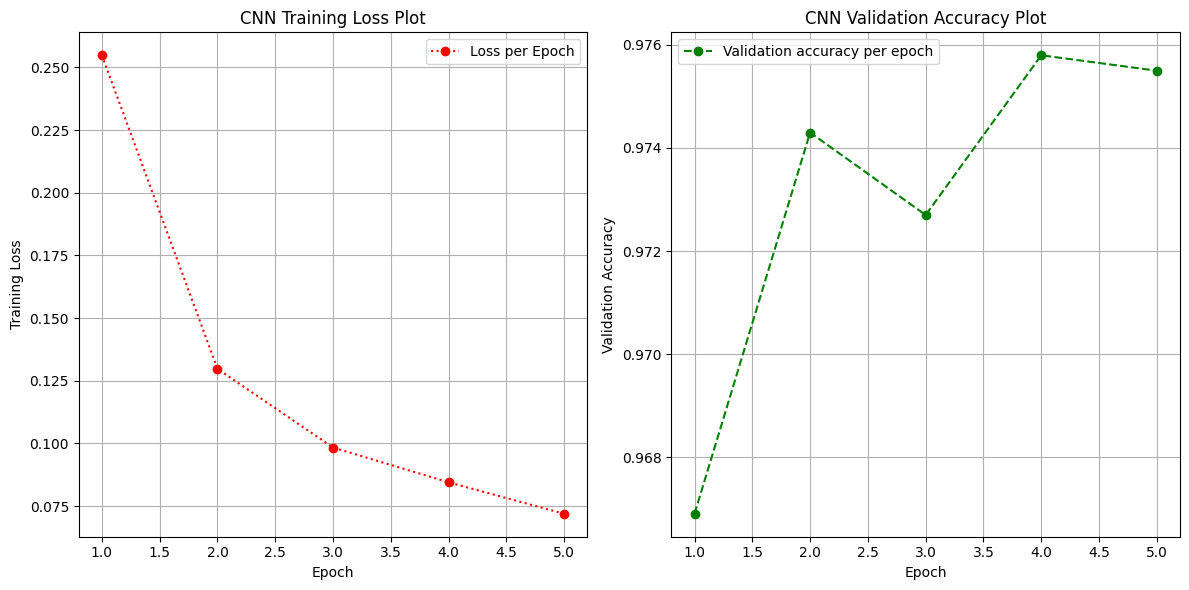

In [29]:
# Plot the training loss and validation accuracy

_,(ax1,ax2) =  plt.subplots(1,2,figsize=(12,6))

ax1.plot(range(1, epochs+1), np.array(model_metrics['Training_Loss']), marker='o', color='r', ls=':', label='Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('CNN Training Loss Plot')
ax1.legend()
ax1.grid()

ax2.plot(range(1, epochs+1),np.array(model_metrics['Validation_Accuracy']), marker = 'o',color = 'g', ls='--',label='Validation accuracy per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('CNN Validation Accuracy Plot')
ax2.legend()
ax2.grid()

plt.tight_layout()

plt.show()


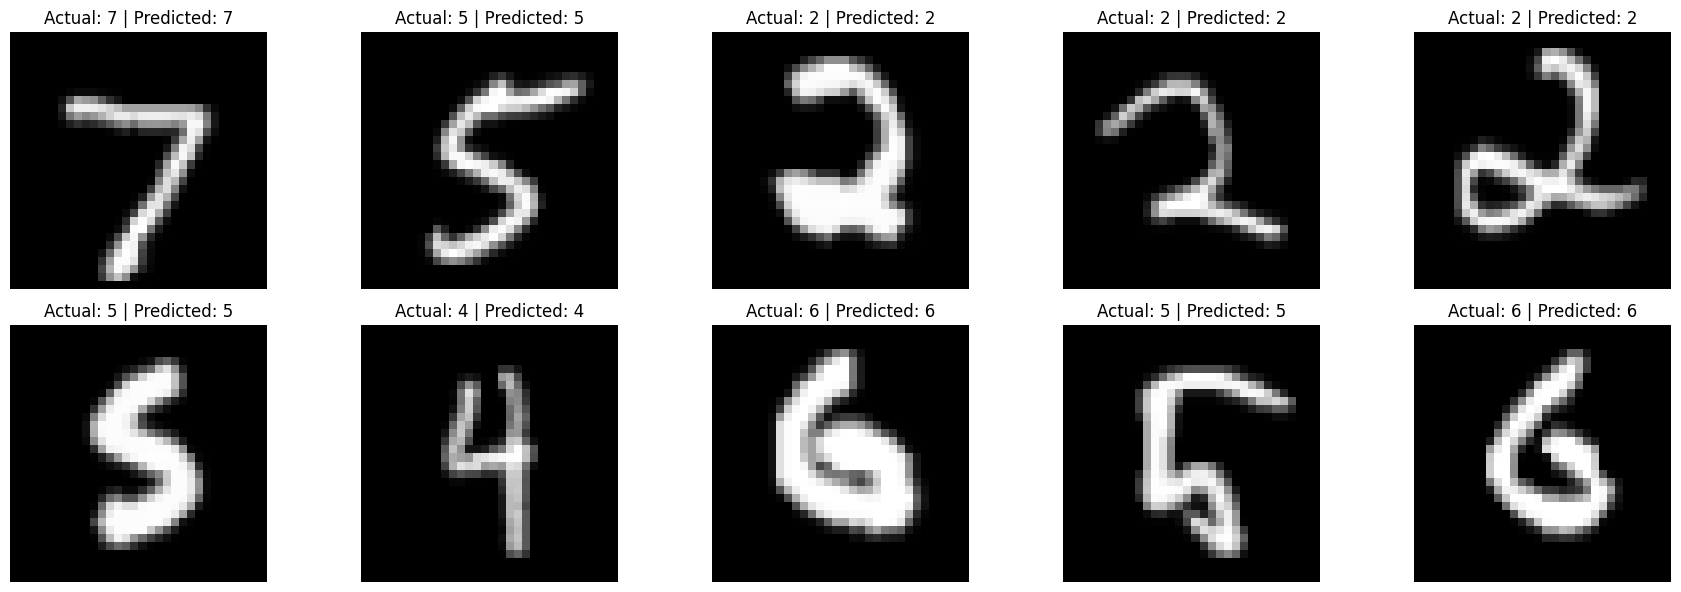

In [30]:
#Plot the actual and predicted labels along the orginal image
model_pretrained.eval()
fig, axes = plt.subplots(2, 5, figsize=(18, 6)) 

axes = axes.flatten()
with torch.no_grad():
    for i, (x, y) in zip(range(10), test_loader):
        z = model_pretrained(x)
        _, yhat = torch.max(z, 1)
        
        axes[i].imshow(x[i][0].numpy(), cmap='gray' )
        axes[i].set_title(f'Actual: {y[i].item()} | Predicted: {yhat[i].item()}')
        axes[i].axis('off')
plt.tight_layout(pad=1.0)
plt.show()